<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/graviational_wave_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Graviational Wave Detection**

In [ ]:
# gwpy and h5py for LIGOs HDF5 data
!pip install h5py gwpy pywt jax jaxlib flax optax matplotlib -q

ERROR: Could not find a version that satisfies the requirement pywt (from versions: none)
ERROR: No matching distribution found for pywt


In [ ]:
import numpy as np
from gwpy.timeseries import TimeSeries
from gwpy.plot import Plot

In [ ]:
!pip install --upgrade gwosc -q

In [ ]:
# gwosc provides access to all detected events
from gwosc import datasets

# List all available events
events = datasets.find_datasets(type="event")
print(f"Available events: {events}")

# Get the GPS time for a specific event
event_name = 'GW150914'
gps_time = datasets.event_gps(event_name)
print(f"GPS Time for {event_name}: {gps_time}")

Available events: ['151008-v1', '151012.2-v1', '151116-v1', '161202-v1', '161217-v1', '170208-v1', '170219-v1', '170405-v1', '170412-v1', '170423-v1', '170616-v1', '170630-v1', '170705-v1', '170720-v1', '190924_232654-v1', '191118_212859-v1', '191223_014159-v1', '191225_215715-v1', '200114_020818-v1', '200121_031748-v1', '200201_203549-v1', '200214_224526-v1', '200214_224526-v2', '200219_201407-v1', '200311_103121-v1', 'GRB051103-v1', 'GW150914-v1', 'GW150914-v2', 'GW150914-v3', 'GW151012-v1', 'GW151012-v2', 'GW151012-v3', 'GW151226-v1', 'GW151226-v2', 'GW170104-v1', 'GW170104-v2', 'GW170608-v1', 'GW170608-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v1', 'GW170814-v2', 'GW170814-v3', 'GW170817-v1', 'GW170817-v2', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1', 'GW190403_051519-v1', 'GW190408_181802-v1', 'GW190408_181802-v2', 'GW190412-v1', 'GW190412-v2', 'GW190412-v3', 'GW190412_053044-v4', 'GW190413_052954-v1', 'GW190413_052954-v2', 'GW190413_134308-v1', 'GW190413_134308-

Download the Data:
* Download the strain data for either the H1 (Hanford) or L1 (Livingston) detector.
* The data will be available in HDF5 format.

You can download the file manually or use the following URL to download strain data directly. This will download the file H-H1_LOSC_4_V2-1126259446-32.hdf5, which contains the raw strain data around the event.

In [ ]:
!wget https://www.gw-openscience.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5

--2024-09-23 06:06:22--  https://www.gw-openscience.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5
Resolving www.gw-openscience.org (www.gw-openscience.org)... 131.215.113.72
Connecting to www.gw-openscience.org (www.gw-openscience.org)|131.215.113.72|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://gwosc.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5 [following]
--2024-09-23 06:06:23--  https://gwosc.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5
Resolving gwosc.org (gwosc.org)... 131.215.113.72
Connecting to gwosc.org (gwosc.org)|131.215.113.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1040592 (1016K)
Saving to: ‘H-H1_LOSC_4_V2-1126259446-32.hdf5’

H-H1_LOSC_4_V2-1126 100%[===================>]   1016K  1.29MB/s    in 0.8s    

2024-09-23 06:06:24 (1.29 MB/s) - ‘H-H1_LOSC_4_V2-1126259446-32.hdf5’ saved [1040592/1040592]



In [ ]:
import h5py

# Path to the downloaded HDF5 file
file_path = 'H-H1_LOSC_4_V2-1126259446-32.hdf5'  # Replace with your file path

# Open the HDF5 file and explore its structure
with h5py.File(file_path, 'r') as f:
    # List all groups and datasets in the file
    print("Keys in the file:", list(f.keys()))

    # Explore the 'strain' group if it exists
    if 'strain' in f.keys():
        strain_group = f['strain']
        print("\nDatasets in 'strain' group:", list(strain_group.keys()))

        # List all attributes in the 'strain' group
        print("\nAttributes in 'strain' group:", list(strain_group.attrs.keys()))

        # If 'SampleRate' exists, print it; otherwise, print a warning
        if 'SampleRate' in strain_group.attrs:
            print("SampleRate:", strain_group.attrs['SampleRate'])
        else:
            print("SampleRate attribute not found.")


Keys in the file: ['meta', 'quality', 'strain']

Datasets in 'strain' group: ['Strain']

Attributes in 'strain' group: []
SampleRate attribute not found.


In [ ]:
import h5py
import numpy as np

# Open the HDF5 file
with h5py.File(file_path, 'r') as f:
    # Check if 'strain' group exists
    if 'strain' in f.keys():
        strain_data = f['strain']['Strain'][:]  # Extract strain data
        print("Strain data shape:", strain_data.shape)

        # Try accessing 'SampleRate', otherwise handle missing attribute
        if 'SampleRate' in f['strain'].attrs:
            sample_rate = f['strain'].attrs['SampleRate']
            print("Sample Rate:", sample_rate, "Hz")
        else:
            print("SampleRate attribute not found.")

        # Extract other attributes (like duration) if available
        if 'Duration' in f['strain'].attrs:
            duration = f['strain'].attrs['Duration']
            print("Duration:", duration, "seconds")
        else:
            print("Duration attribute not found.")


Strain data shape: (131072,)
SampleRate attribute not found.
Duration attribute not found.


Manual Handling of Missing Metadata

If critical metadata like `SampleRate` or `Duration` is missing from the file, you can manually set typical values based on LIGO's data standards:
- **Sample Rate**: Typically, LIGO data has a sample rate of **4096 Hz** or **16384 Hz**.
- **Duration**: This can be inferred from the data array length and the sample rate.

For example, if you don’t find the sample rate attribute, you can manually set it to **4096 Hz**:

In [ ]:
# Set default sample rate if not found
sample_rate = 4096  # Assuming 4096 Hz is the sample rate if not available in attributes
duration = len(strain_data) / sample_rate
print(f"Inferred Duration: {duration} seconds based on sample rate {sample_rate} Hz")


Inferred Duration: 32.0 seconds based on sample rate 4096 Hz


* gwpy is used to download and process LIGO data.
* pywt is used for continuous wavelet transforms.
* flax, jax, and optax are for neural network modeling.

Load Real Gravitational Wave Data
LIGO open data is available via GWPy, which allows you to download specific events. Here’s how you load and preprocess the real gravitational wave data:

In [ ]:
import numpy as np
from gwpy.timeseries import TimeSeries

# Download LIGO's open data for a specific event (GW150914 as an example)
def load_ligo_event_data(event='GW150914'):
    start_time = 1126259462  # GW150914 start time
    end_time = start_time + 32  # 32 seconds of data

    # Download strain data for both Hanford and Livingston detectors
    h_data = TimeSeries.fetch_open_data('H1', start_time, end_time, cache=True)
    l_data = TimeSeries.fetch_open_data('L1', start_time, end_time, cache=True)

    return h_data, l_data

# Load data for both detectors
hanford_data, livingston_data = load_ligo_event_data()

# Resample data to a lower sample rate for easier computation
sample_rate = 4096  # LIGO's default is 16384, but downsample to 4096 for performance
hanford_data = hanford_data.resample(sample_rate)
livingston_data = livingston_data.resample(sample_rate)

# Extract raw data arrays
h_strain = hanford_data.value
l_strain = livingston_data.value


/usr/local/lib/python3.10/dist-packages/gwpy/timeseries/timeseries.py:930: UserWarning: resample() rate matches current sample_rate (4096.0 Hz), returning input data unmodified; please double-check your parameters
  warnings.warn(


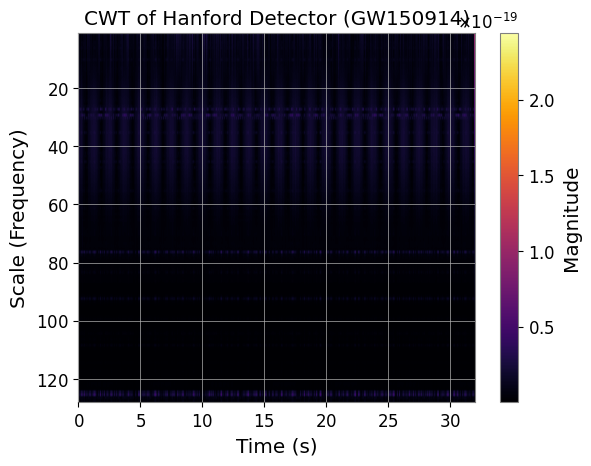

In [ ]:
import pywt
import matplotlib.pyplot as plt

# Perform Continuous Wavelet Transform (CWT) on the strain data
def cwt_transform(strain_data, wavelet='morl', scales=np.arange(1, 128)):
    coeffs, freqs = pywt.cwt(strain_data, scales, wavelet, 1 / sample_rate)
    return coeffs

# Apply CWT to the Hanford data
cwt_hanford = cwt_transform(h_strain)

# Visualize the time-frequency representation
plt.imshow(np.abs(cwt_hanford), aspect='auto', cmap='inferno', extent=[0, len(h_strain)/sample_rate, 1, 128])
plt.gca().invert_yaxis()
plt.colorbar(label='Magnitude')
plt.title('CWT of Hanford Detector (GW150914)')
plt.xlabel('Time (s)')
plt.ylabel('Scale (Frequency)')
plt.show()


Prepare Data for Neural Network Input: To feed the data into a neural network, we’ll treat the CWT output as an image. Each time-series transforms into a 2D matrix (time vs. frequency scale) similar to an image's pixel matrix.
For simplicity, I’ll create a dataset with both signal and noise samples.

In [ ]:
# Generate synthetic noise data for classification (replace with more real data if available)
def generate_synthetic_noise(length, sample_rate):
    noise = np.random.normal(0, 1, length)
    return noise

# Simulate noise data
noise_h_strain = generate_synthetic_noise(len(h_strain), sample_rate)

# Convert both the real signal and noise into CWT format
cwt_noise = cwt_transform(noise_h_strain)

# Stack CWT data from signal and noise for training
X_train = np.stack([np.abs(cwt_hanford), np.abs(cwt_noise)])
y_train = np.array([1, 0])  # 1 = signal, 0 = noise

# Normalize the data
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_train = X_train[..., np.newaxis]  # Add channel dimension for CNN


Define a CNN with JAX and Flax:
We will use Flax to define a more sophisticated CNN to process the time-frequency representation of the gravitational waves:

In [ ]:
!pip install flax optax -q

In [ ]:
class TimeFrequencyCNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=32, kernel_size=(5, 5), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=64, kernel_size=(3, 3), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=128, kernel_size=(3, 3), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        # Print the shape of the feature map before flattening
        print("Shape before flattening:", x.shape)

        x = x.reshape((x.shape[0], -1))  # Flatten the feature map

        # Adjust the input size of Dense layer based on the flattened shape
        x = nn.Dense(256)(x)
        x = nn.relu(x)
        x = nn.Dropout(0.5)(x, deterministic=False)

        x = nn.Dense(2)(x)  # Output layer for binary classification (signal vs noise)
        return x


In [ ]:
class TimeFrequencyCNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=32, kernel_size=(5, 5), strides=(2, 2))(x)  # Increased stride
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=64, kernel_size=(3, 3), strides=(2, 2))(x)  # Increased stride
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=128, kernel_size=(3, 3), strides=(2, 2))(x)  # Increased stride
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        # Print the shape of the feature map before flattening
        print("Shape before flattening:", x.shape)

        x = x.reshape((x.shape[0], -1))  # Flatten the feature map

        x = nn.Dense(256)(x)  # Input size should now match the feature map size
        x = nn.relu(x)
        x = nn.Dropout(0.5)(x, deterministic=False)

        x = nn.Dense(2)(x)  # Output layer for binary classification
        return x


In [ ]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state  # Flax utility for training state
import optax  # Optimization library

# Define the CNN model using Flax's linen module
class TimeFrequencyCNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=32, kernel_size=(5, 5), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=64, kernel_size=(3, 3), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = nn.Conv(features=128, kernel_size=(3, 3), strides=(1, 1))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, (2, 2), (2, 2))

        x = x.reshape((x.shape[0], -1))  # Flatten the feature map
        x = nn.Dense(256)(x)
        x = nn.relu(x)
        x = nn.Dropout(0.5)(x, deterministic=False)

        x = nn.Dense(2)(x)  # Output layer for binary classification (signal vs noise)
        return x

# Initialize the model
rng = jax.random.PRNGKey(42)
model = TimeFrequencyCNN()
params = model.init(rng, jnp.ones((1, 128, 128, 1)))['params']

# Optimizer setup using optax
learning_rate = 0.001
optimizer = optax.adam(learning_rate)

# Flax's built-in TrainState class to manage parameters, optimizer, and apply gradients
class TrainState(train_state.TrainState):
    pass

# Initialize the training state
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

# Training step function (JIT compiled with static argument for speed)
@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        logits = state.apply_fn({'params': params}, batch['X'], mutable=['dropout'])
        loss = optax.softmax_cross_entropy(logits, jax.nn.one_hot(batch['y'], 2)).mean()
        return loss

    # Compute gradients and apply them
    grads = jax.grad(loss_fn)(state.params)
    new_state = state.apply_gradients(grads=grads)
    return new_state

# Example training loop
batch = {'X': X_train, 'y': y_train}  # Sample batch with X_train and y_train (already defined)

# Train for a few epochs (adjust as needed)
for epoch in range(10):
    state = train_step(state, batch)
    print(f'Epoch {epoch + 1} completed.')
